# 05 — Evaluation, Threshold Optimization & Explainability

The winning pipeline was refit on train, its **decision threshold chosen on validation** to minimize
business cost — `cost = Σ(amount of missed frauds) + $5 × false alarms` — then evaluated **once** on
the held-out test set.

In [1]:
import sys, warnings
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))
warnings.filterwarnings("ignore")
%load_ext autoreload
%autoreload 2

import pandas as pd
from IPython.display import Image, display
from src.utils import load_config, resolve_path

config = load_config()
pd.set_option("display.max_columns", 40)

In [2]:
from src.utils import load_json
meta = load_json(resolve_path(config["paths"]["artifacts_dir"]) / "model_metadata.json")
ev = load_json(resolve_path(config["paths"]["artifacts_dir"]) / "test_evaluation.json")
print(f"Champion: {meta['model']} + {meta['strategy']} | tuned threshold = {meta['threshold']:.3f}")
pd.DataFrame({"default 0.50": ev["default_threshold"], f"tuned {meta['threshold']:.3f}": ev["tuned_threshold"]})

Champion: xgboost + class_weight | tuned threshold = 0.669


,default 0.50,tuned 0.669
threshold,0.500000,0.669000
precision,0.947368,0.960000
recall,0.757895,0.757895
f1,0.842105,0.847059
roc_auc,0.973310,0.973310
pr_auc,0.821226,0.821226
tn,56647.000000,56648.000000
fp,4.000000,3.000000
fn,23.000000,23.000000
tp,72.000000,72.000000


## Threshold: why not 0.5?

0.5 is only "neutral" if false positives and false negatives cost the same — here they differ by
orders of magnitude. The cost curve below (computed on validation) shows the optimum; the confusion
matrices show what the shift does on the test set.

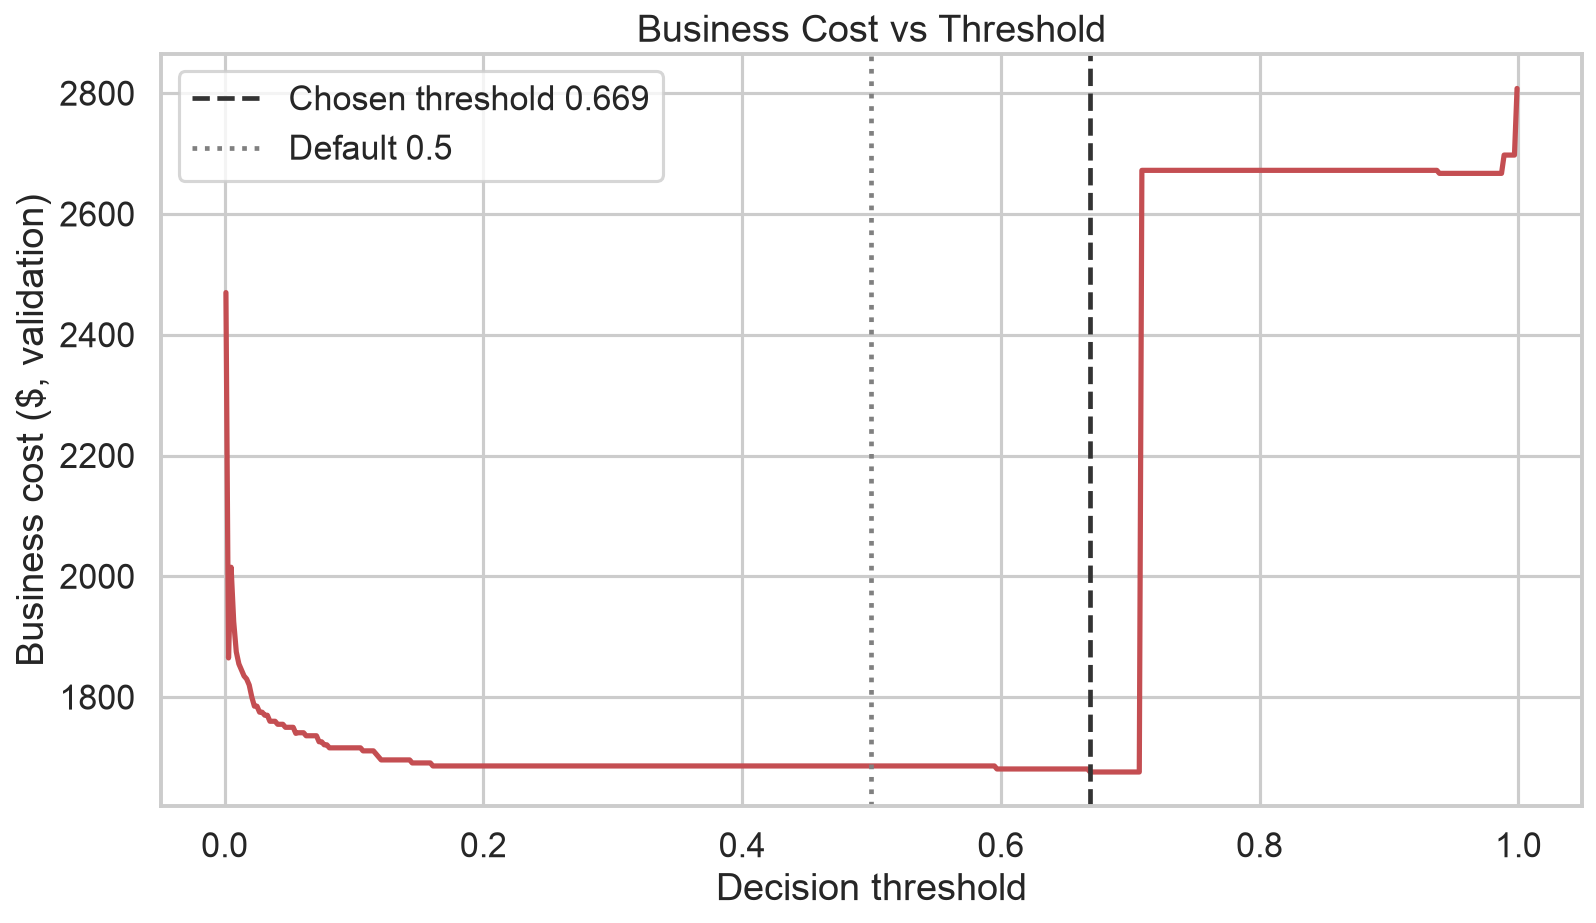

In [3]:
display(Image(str(resolve_path(config["paths"]["images_dir"]) / "threshold_cost_curve.png")))

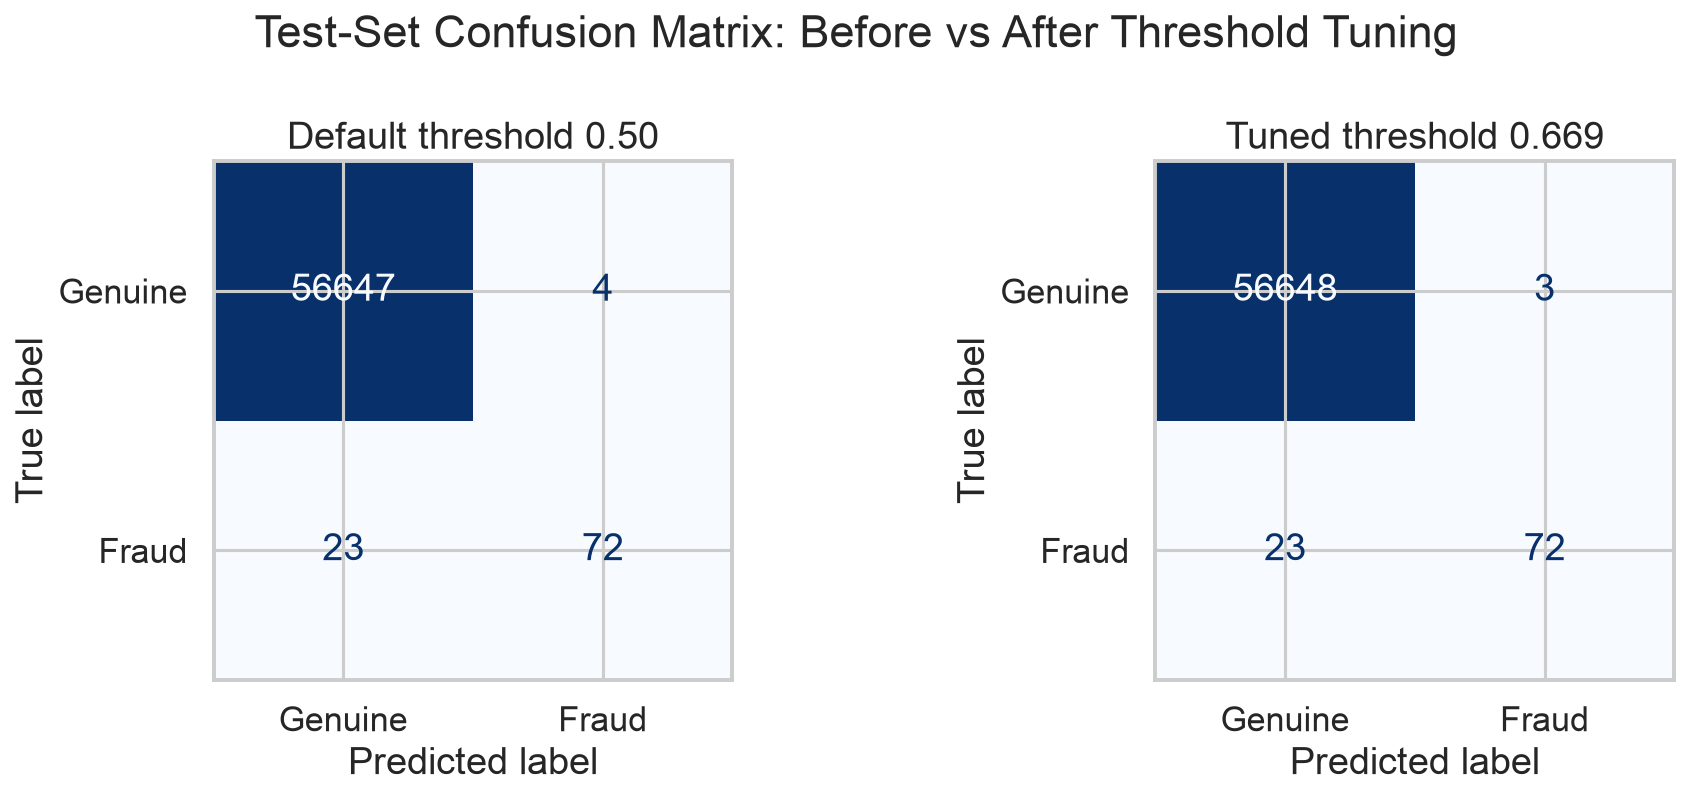

In [4]:
display(Image(str(resolve_path(config["paths"]["images_dir"]) / "confusion_matrices.png")))

## ROC vs Precision-Recall

ROC-AUC looks near-perfect — with 56,651 genuine vs 95 fraud test rows, the false-positive *rate*
stays microscopic no matter what. The PR curve tells the honest story: precision visibly trades off
against recall. This contrast is the canonical argument for PR-AUC under extreme imbalance.

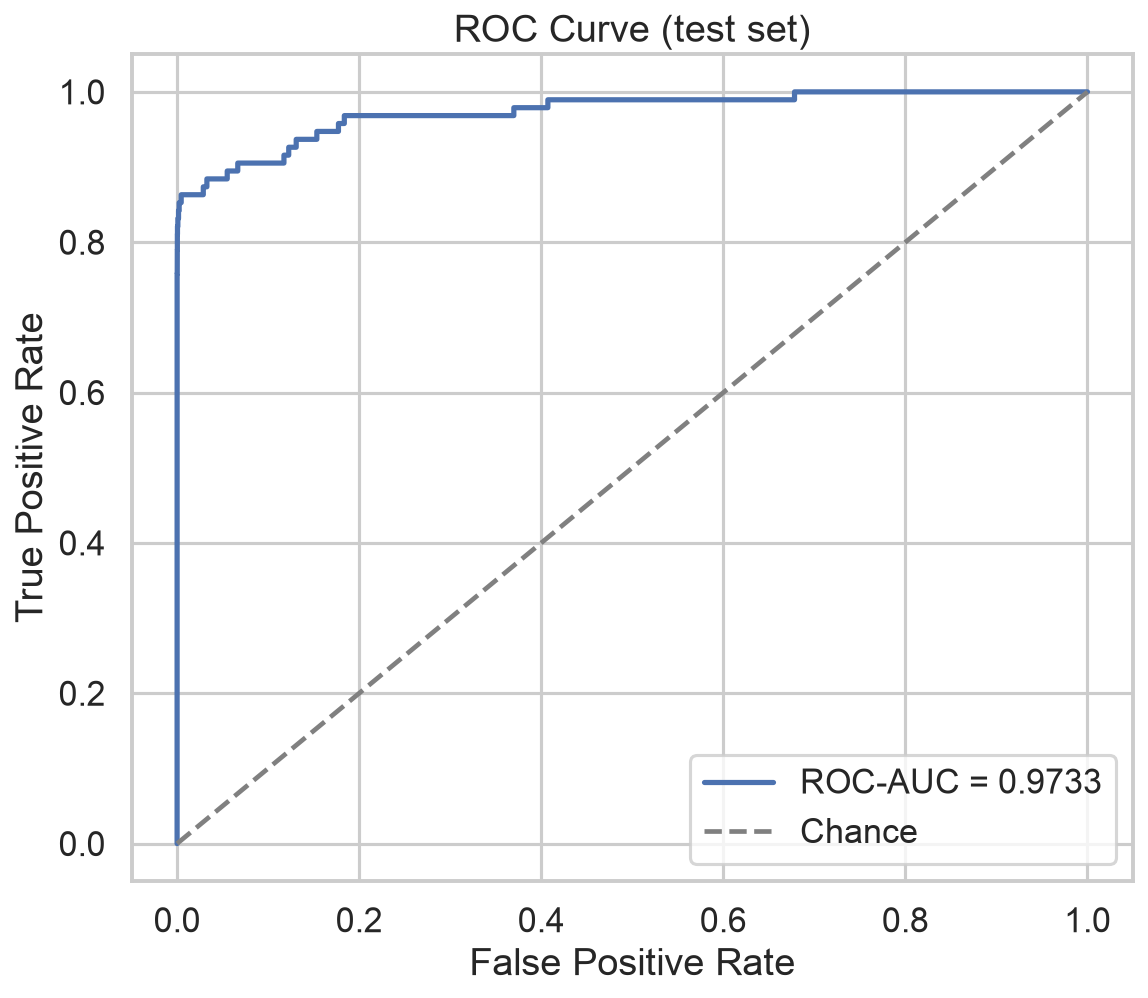

In [5]:
display(Image(str(resolve_path(config["paths"]["images_dir"]) / "roc_curve.png")))

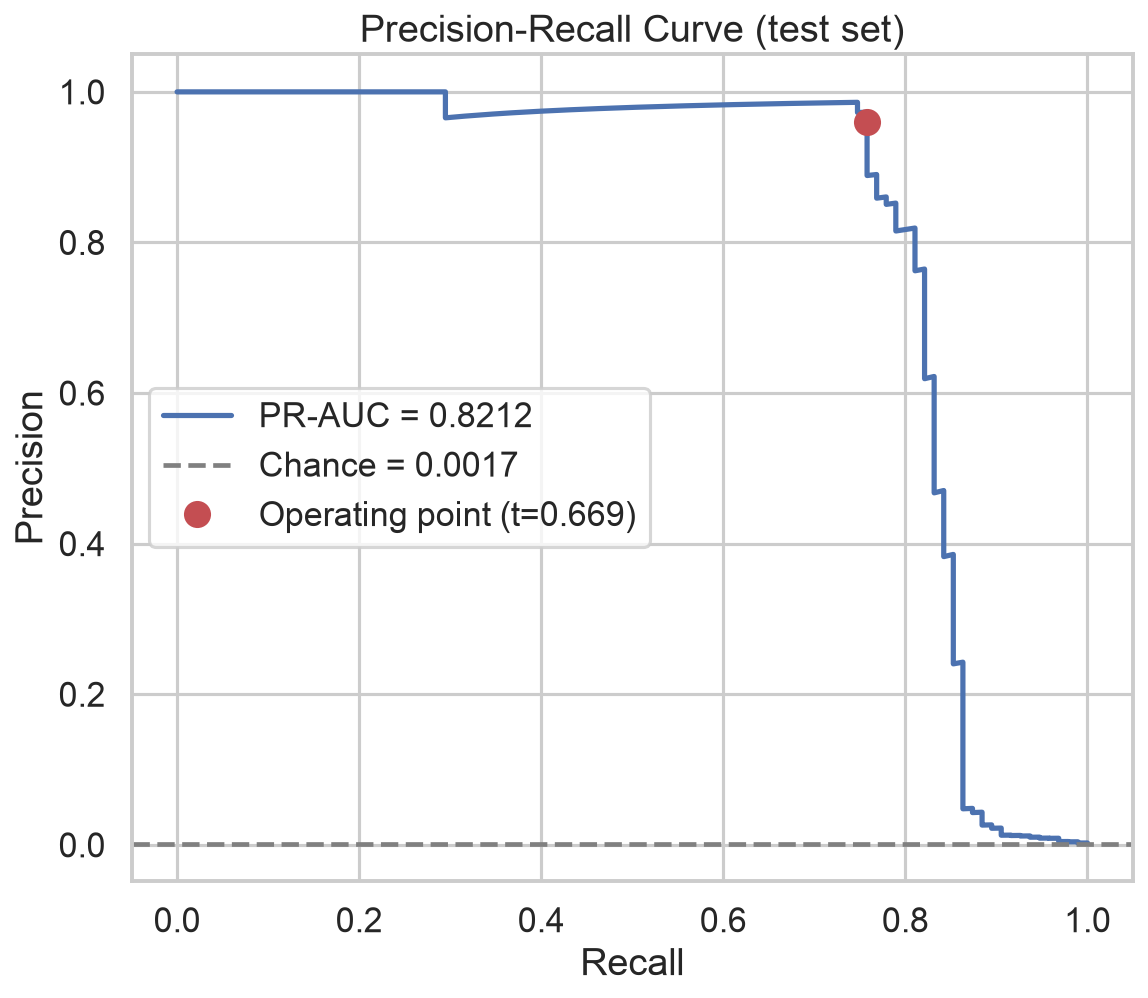

In [6]:
display(Image(str(resolve_path(config["paths"]["images_dir"]) / "pr_curve.png")))

## Business cost analysis

In [7]:
bc = ev["business_cost"]
pd.Series(bc).to_frame("value")

,value
no_model_cost,14766.31
default_cost,3832.28
tuned_cost,3827.28
fp_unit_cost,5.00
savings_vs_no_model_pct,74.10


## Explainability

**Permutation importance** (drop in PR-AUC when a feature is shuffled) is model-agnostic evidence of
what the model actually uses. **SHAP** attributes each individual prediction to features; the beeswarm
shows direction — e.g. strongly negative V14 pushes predictions toward fraud. The top features
(V14, V10, V12, V4, V17) are exactly the ones EDA flagged as most class-separating — a consistency
check across the whole project.

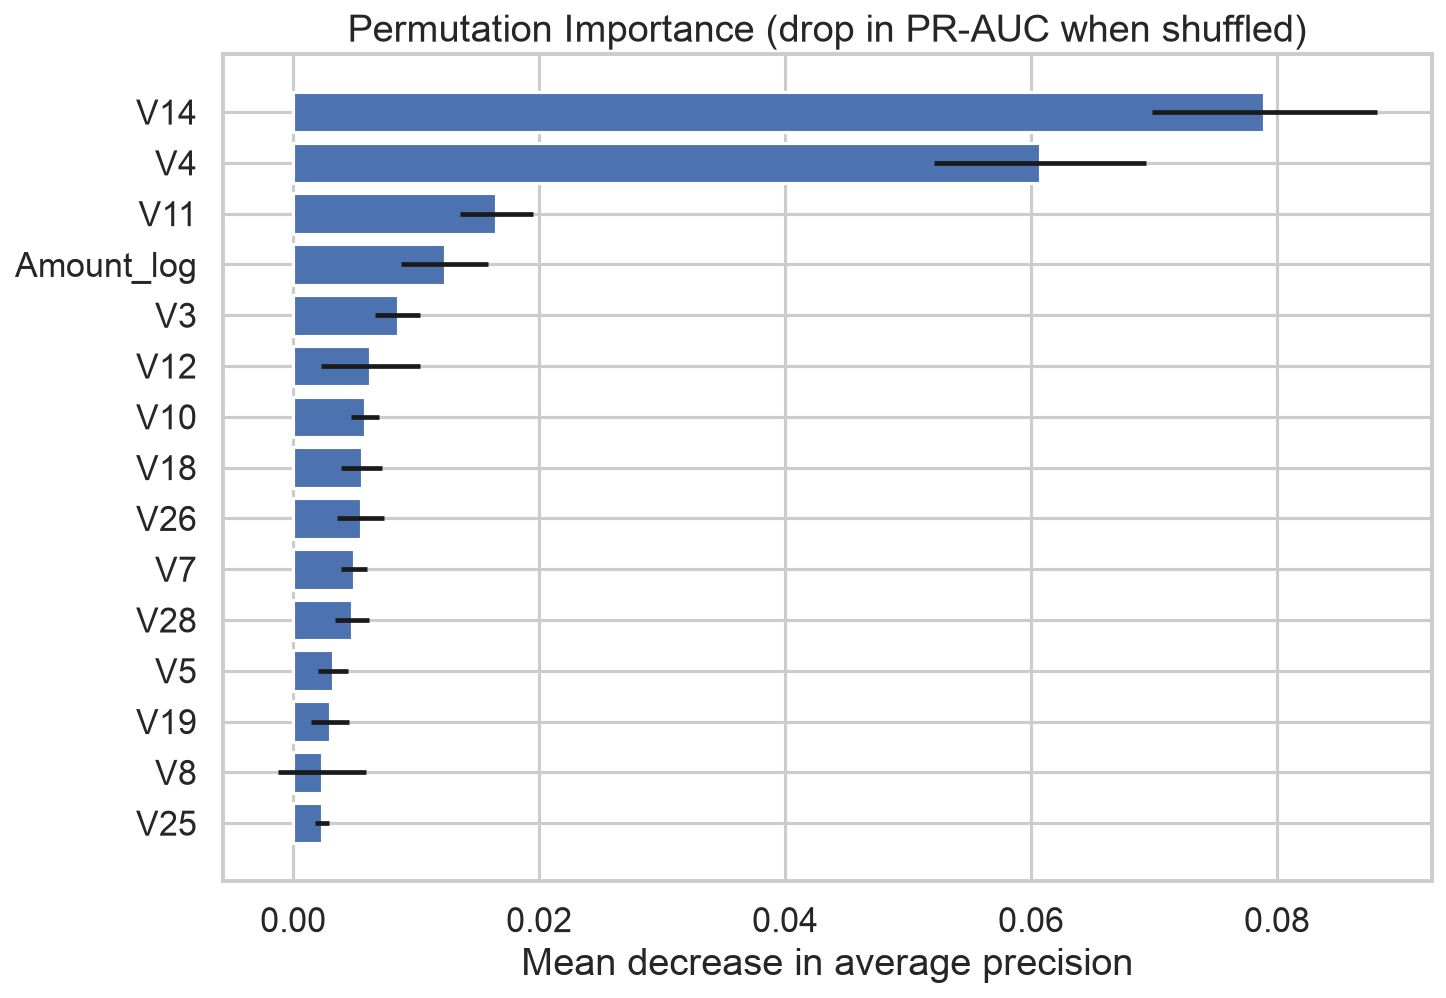

In [8]:
display(Image(str(resolve_path(config["paths"]["images_dir"]) / "permutation_importance.png")))

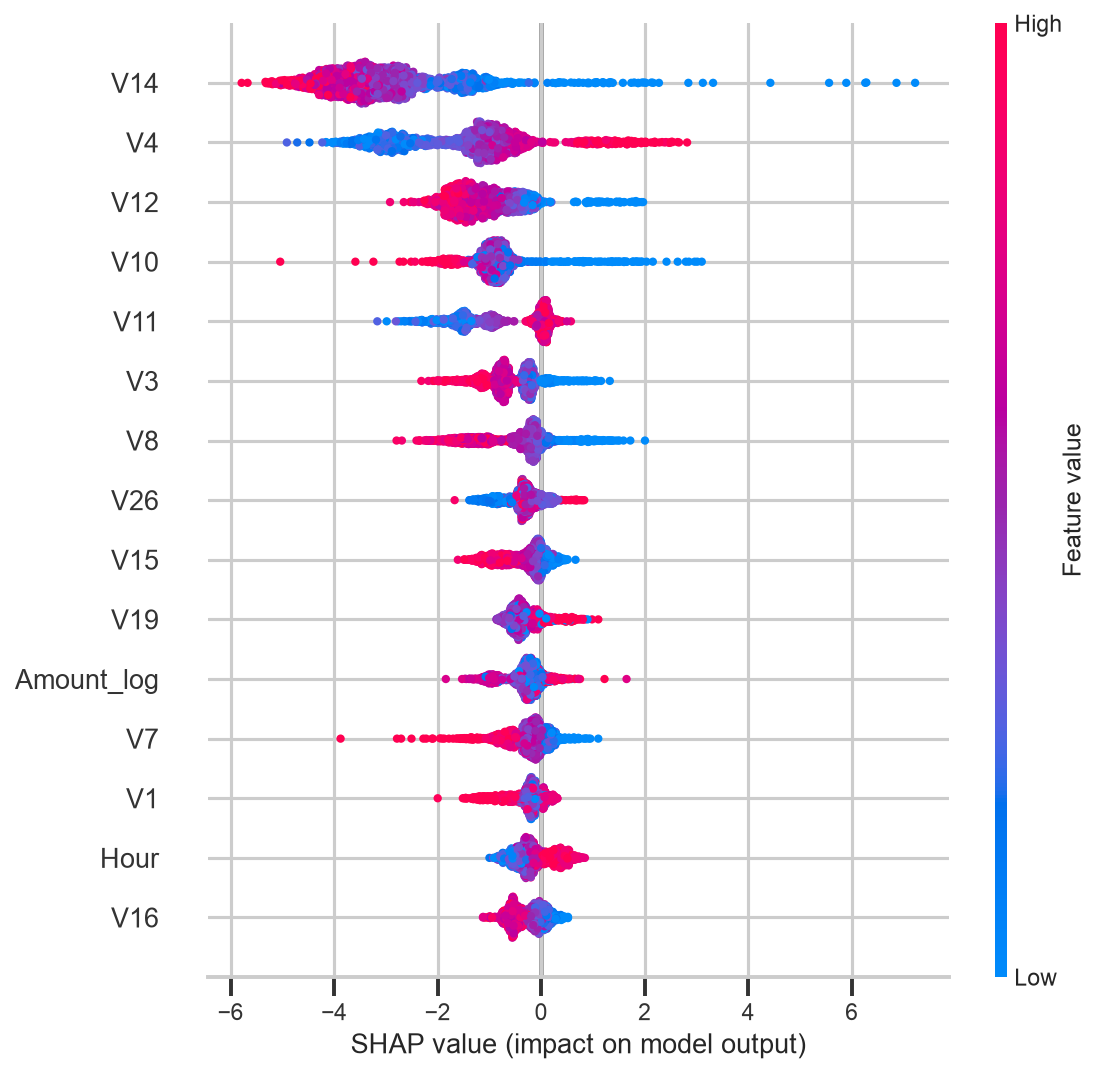

In [9]:
display(Image(str(resolve_path(config["paths"]["images_dir"]) / "shap_summary.png")))

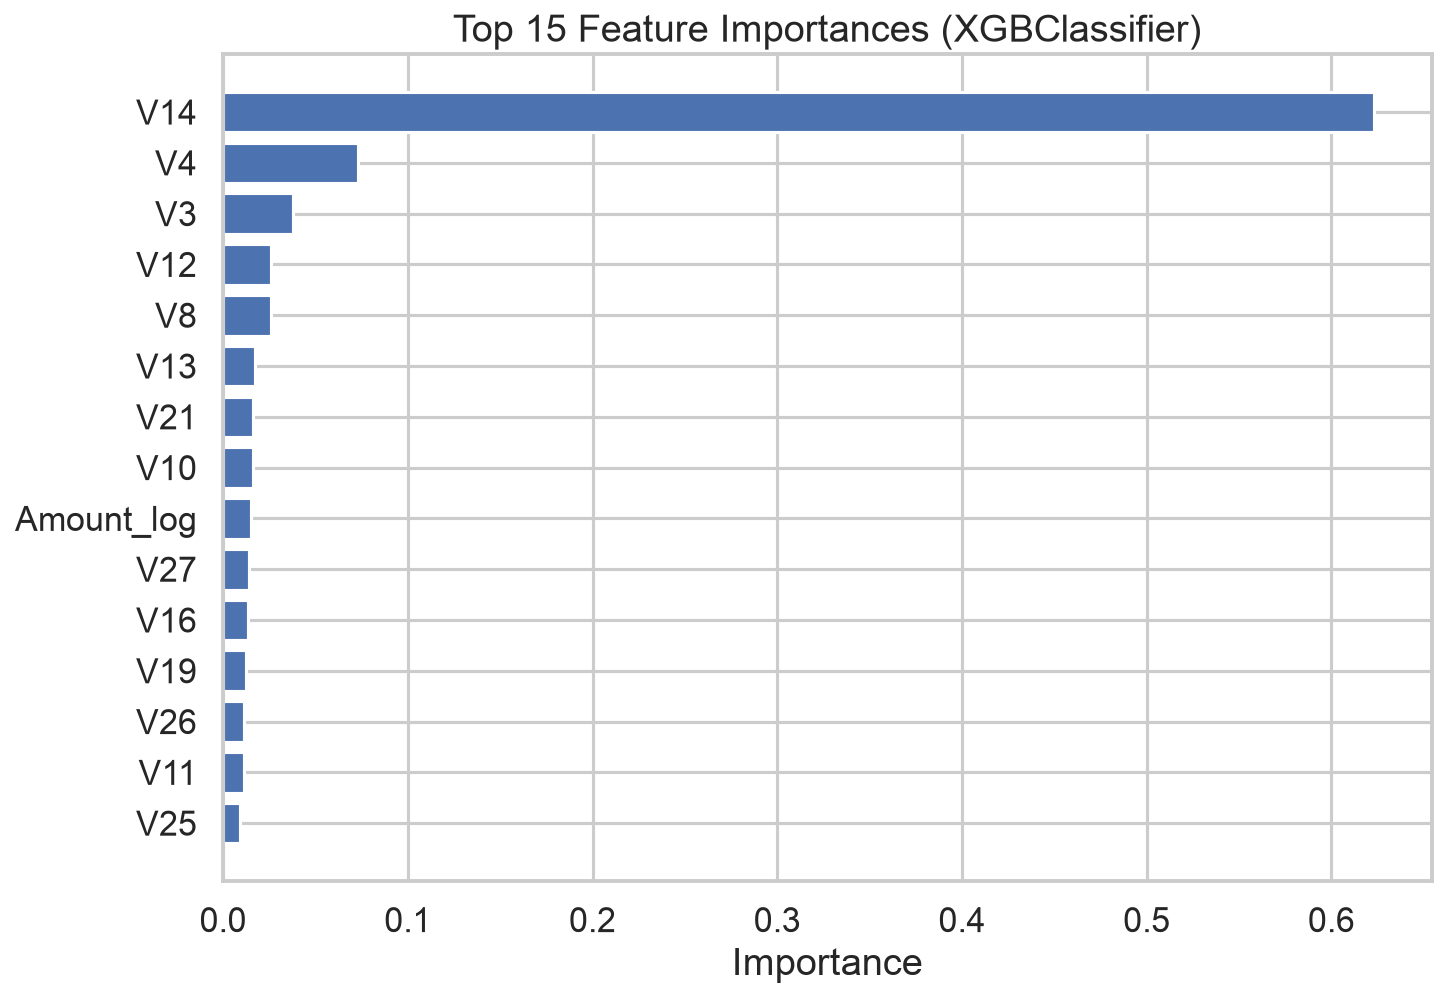

In [10]:
display(Image(str(resolve_path(config["paths"]["images_dir"]) / "feature_importance.png")))

## Inference smoke test

The deployable API: raw transaction in → probability, class, risk level out.

In [11]:
from src.inference import FraudDetector
from src.data_loader import load_raw_data

detector = FraudDetector.load()
df = load_raw_data(config)
fraud_txn = df[df.Class == 1].iloc[0].drop("Class").to_dict()
genuine_txn = df[df.Class == 0].iloc[0].drop("Class").to_dict()
print("known fraud   ->", detector.predict_one(fraud_txn))
print("known genuine ->", detector.predict_one(genuine_txn))

2026-07-31 18:15:12 | INFO    | src.inference | Loaded xgboost + class_weight (threshold=0.669)


2026-07-31 18:15:13 | INFO    | src.data_loader | Loaded raw data: 284807 rows x 31 columns


2026-07-31 18:15:13 | INFO    | src.feature_engineering | Feature engineering done: 31 columns (['hour', 'amount_log'] added, ['Time'] dropped)


2026-07-31 18:15:13 | INFO    | src.inference | Scored batch of 1 transactions (1 flagged)


2026-07-31 18:15:13 | INFO    | src.feature_engineering | Feature engineering done: 31 columns (['hour', 'amount_log'] added, ['Time'] dropped)


2026-07-31 18:15:13 | INFO    | src.inference | Scored batch of 1 transactions (0 flagged)


known fraud   -> {'fraud_probability': 0.9997190237045288, 'prediction': 1, 'risk_level': 'HIGH', 'threshold': 0.669}
known genuine -> {'fraud_probability': 9.999999974752427e-07, 'prediction': 0, 'risk_level': 'LOW', 'threshold': 0.669}
